# AWS SageMaker — Deploying a Model to a Managed Endpoint

AWS SageMaker is Amazon's managed ML platform. It handles the infrastructure for training, hosting, and monitoring your models so you don't have to manage EC2 instances or load balancers yourself.

This notebook walks through every step of the SageMaker deployment flow using real boto3 API calls. Since you likely don't have AWS credentials in this environment, every call is wrapped in `try/except` to catch authentication errors and print what the call would do in production.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 4, lesson 03 "03. Implementing ML Models Using Scikit-learn" — the fitted estimator from that lesson is literally what gets tarred, uploaded to S3 and hosted here; SageMaker changes where the model runs, not what it is.


## 📰 AWS shipped a whole product because idle endpoints were bankrupting people

A SageMaker real-time endpoint is billed **per instance-hour for as long as it is `InService`**, whether it answers a million requests or none. That property is so consistently painful that on **21 April 2022** AWS made **SageMaker Serverless Inference** generally available, whose entire pitch is the sentence in its launch announcement: *"you pay only for the compute capacity used to process inference requests (billed by the millisecond) and the amount of data processed; you do not pay for idle time."*

Read that as a company publicly documenting the failure mode of its own earlier design. The classic student and start-up story is the same every time: deploy an endpoint to demo a model, forget it, and discover a four-figure bill a month later — for an endpoint that served eleven requests. Section 9 of this notebook is not housekeeping. It is the most financially consequential cell in the unit.

**What goes wrong without this lesson.** Without a managed endpoint you build the load balancer, the auto-scaler, the health checks and the deployment pipeline yourself. With one, you inherit a billing model and a set of platform-specific objects whose relationships you must understand — because Model, EndpointConfig and Endpoint are separate for a reason, and that reason is how you update and roll back a model without dropping traffic.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain the SageMaker deployment flow from local model to live endpoint
2. Create the `model.tar.gz` artifact format SageMaker expects
3. Read and understand the boto3 calls for `create_model`, `create_endpoint_config`, and `create_endpoint`
4. Invoke a SageMaker endpoint and interpret the response
5. Set up auto-scaling and delete an endpoint to stop billing

## 1. SageMaker Architecture

SageMaker has three layers that work together:

```
Your model artifact (S3)
      |
      v
SageMaker Model  <-- points to S3 path + inference container image
      |
      v
Endpoint Config  <-- defines instance type, count, traffic splits
      |
      v
Endpoint         <-- the live HTTPS URL your application calls
```

Separating the **Model** from the **Endpoint Config** from the **Endpoint** lets you:
- Swap a new model version without touching the config
- Run A/B tests by routing traffic to two model variants in one endpoint config
- Rollback by repointing the endpoint to a previous config

## 2. Train a Model and Create the SageMaker Artifact

In [1]:
# WHAT: train the iris model locally and stage model.joblib + scaler.joblib.
# WHY: SageMaker separates training from hosting — we play the training side
# here, producing the files the hosted endpoint will later load.
import os
import tarfile
import pathlib
import joblib
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train a simple classifier
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_s, y_train)

print(f"Model trained. Test accuracy: {clf.score(scaler.transform(X_test), y_test):.2%}")

# Save model artifacts to a staging directory
staging_dir = pathlib.Path('/tmp/sagemaker_staging')
staging_dir.mkdir(exist_ok=True)

joblib.dump(clf, staging_dir / 'model.joblib')
joblib.dump(scaler, staging_dir / 'scaler.joblib')
print(f"Saved model.joblib and scaler.joblib to {staging_dir}")

Model trained. Test accuracy: 100.00%
Saved model.joblib and scaler.joblib to /tmp/sagemaker_staging


In [2]:
# SageMaker expects a tar.gz archive named model.tar.gz
# Inside it, the inference container looks for model artifacts at a known path

ARTIFACT_PATH = '/tmp/model.tar.gz'

with tarfile.open(ARTIFACT_PATH, 'w:gz') as tar:
    tar.add(staging_dir / 'model.joblib', arcname='model.joblib')
    tar.add(staging_dir / 'scaler.joblib', arcname='scaler.joblib')

size_kb = os.path.getsize(ARTIFACT_PATH) / 1024
print(f"Created: {ARTIFACT_PATH}  ({size_kb:.1f} KB)")

# Verify the archive contents
with tarfile.open(ARTIFACT_PATH, 'r:gz') as tar:
    print("Archive contents:")
    for member in tar.getmembers():
        print(f"  {member.name:30s} {member.size:,} bytes")

Created: /tmp/model.tar.gz  (22.7 KB)
Archive contents:
  model.joblib                   186,929 bytes
  scaler.joblib                  679 bytes


## 3. Upload the Artifact to S3

SageMaker pulls the model artifact from S3 when it starts the endpoint. The `s3_model_uri` is what you give to `create_model()` later.

In [3]:
# WHAT: upload the model.tar.gz to S3 — or, without AWS credentials, show exactly
# what would be uploaded and where.
# WHY: SageMaker can only deploy from S3; the try/except pattern lets this lesson
# run for every student while teaching the real call and its failure modes.
import boto3
from botocore.exceptions import NoCredentialsError, ClientError

BUCKET_NAME = 'my-ml-models-bucket-replace-me'
S3_KEY = 'iris-classifier/v1/model.tar.gz'

try:
    s3 = boto3.client('s3', region_name='us-east-1')
    s3.upload_file(ARTIFACT_PATH, BUCKET_NAME, S3_KEY)
    s3_model_uri = f's3://{BUCKET_NAME}/{S3_KEY}'
    print(f"Uploaded to: {s3_model_uri}")

# No AWS account in class: keep the URI so later cells can still build on it.
except NoCredentialsError:
    s3_model_uri = f's3://{BUCKET_NAME}/{S3_KEY}'  # set for later cells
    print("[No credentials] In production, set AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY.")
    print(f"The upload command would put the artifact at: {s3_model_uri}")

# Real AWS rejections (bad bucket, permissions) surface with their error code.
except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")
    s3_model_uri = f's3://{BUCKET_NAME}/{S3_KEY}'

[No credentials] In production, set AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY.
The upload command would put the artifact at: s3://my-ml-models-bucket-replace-me/iris-classifier/v1/model.tar.gz


## 4. Create the SageMaker Model

A SageMaker **Model** object registers:
- Where the artifact lives (S3 URI)
- Which Docker container image to use for inference
- The IAM role that the endpoint can use to access S3

In [4]:
# WHAT: register the artifact as a SageMaker Model — container image + S3 data + IAM role.
# WHY: a 'Model' in SageMaker is the pairing of YOUR weights with AWS's serving
# container; the ECR image URI is how you pick the sklearn runtime.
import json

# SageMaker built-in containers are identified by ECR image URIs
# This is the sklearn inference container for us-east-1
SKLEARN_IMAGE_URI = '683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3'
EXECUTION_ROLE_ARN = 'arn:aws:iam::123456789012:role/SageMakerExecutionRole'
MODEL_NAME = 'iris-classifier-v1'

# The three essentials: which container, which artifact, which permissions.
create_model_params = {
    'ModelName': MODEL_NAME,
    'PrimaryContainer': {
        'Image': SKLEARN_IMAGE_URI,
        'ModelDataUrl': s3_model_uri,
        'Environment': {
            'SAGEMAKER_PROGRAM': 'inference.py',
            'SAGEMAKER_SUBMIT_DIRECTORY': s3_model_uri,
        }
    },
    'ExecutionRoleArn': EXECUTION_ROLE_ARN,
}

try:
    sm = boto3.client('sagemaker', region_name='us-east-1')
    response = sm.create_model(**create_model_params)
    print(f"Model created: {response['ModelArn']}")

# Without credentials we print the exact API payload instead of sending it.
except NoCredentialsError:
    print("[No credentials] Would call: sagemaker.create_model()")
    print("Parameters that would be sent:")
    print(json.dumps(create_model_params, indent=2))

except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would call: sagemaker.create_model()
Parameters that would be sent:
{
  "ModelName": "iris-classifier-v1",
  "PrimaryContainer": {
    "Image": "683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3",
    "ModelDataUrl": "s3://my-ml-models-bucket-replace-me/iris-classifier/v1/model.tar.gz",
    "Environment": {
      "SAGEMAKER_PROGRAM": "inference.py",
      "SAGEMAKER_SUBMIT_DIRECTORY": "s3://my-ml-models-bucket-replace-me/iris-classifier/v1/model.tar.gz"
    }
  },
  "ExecutionRoleArn": "arn:aws:iam::123456789012:role/SageMakerExecutionRole"
}


## 5. Create an Endpoint Configuration

The endpoint config specifies the instance type and how many instances to run. It is separate from the endpoint so you can update the config independently and then apply it in a blue/green deployment.

In [5]:
# WHAT: create the endpoint CONFIG — instance type, count, and traffic weight.
# WHY: config is separate from the endpoint on purpose: blue/green and A/B
# deployments work by swapping configs under the same endpoint name.
ENDPOINT_CONFIG_NAME = 'iris-classifier-config-v1'

endpoint_config_params = {
    'EndpointConfigName': ENDPOINT_CONFIG_NAME,
    'ProductionVariants': [
        {
            'VariantName': 'primary',
            'ModelName': MODEL_NAME,
            'InstanceType': 'ml.m5.large',   # 2 vCPU, 8 GB RAM, ~$0.115/hr
            'InitialInstanceCount': 1,
            'InitialVariantWeight': 1.0,
        }
    ]
}

try:
    sm = boto3.client('sagemaker', region_name='us-east-1')
    response = sm.create_endpoint_config(**endpoint_config_params)
    print(f"Endpoint config created: {response['EndpointConfigArn']}")

# Teaching fallback: show the parameters the call would send.
except NoCredentialsError:
    print("[No credentials] Would call: sagemaker.create_endpoint_config()")
    print("Parameters that would be sent:")
    print(json.dumps(endpoint_config_params, indent=2))

except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would call: sagemaker.create_endpoint_config()
Parameters that would be sent:
{
  "EndpointConfigName": "iris-classifier-config-v1",
  "ProductionVariants": [
    {
      "VariantName": "primary",
      "ModelName": "iris-classifier-v1",
      "InstanceType": "ml.m5.large",
      "InitialInstanceCount": 1,
      "InitialVariantWeight": 1.0
    }
  ]
}


## 6. Deploy the Endpoint

Creating the endpoint provisions the infrastructure. This takes 3–10 minutes in production. The endpoint status moves from `Creating` → `InService`.

In [6]:
# WHAT: create the endpoint itself and wait until it reports InService.
# WHY: this is the step that provisions billable instances — from here on the
# model has an HTTPS URL and you are paying by the hour.
ENDPOINT_NAME = 'iris-classifier-endpoint'

create_endpoint_params = {
    'EndpointName': ENDPOINT_NAME,
    'EndpointConfigName': ENDPOINT_CONFIG_NAME,
}

try:
    sm = boto3.client('sagemaker', region_name='us-east-1')
    response = sm.create_endpoint(**create_endpoint_params)
    print(f"Endpoint creation started: {response['EndpointArn']}")
    print("Polling for status...")

    # In production: wait for endpoint to be InService
    # Endpoints take minutes to start; the waiter polls status until ready.
    waiter = sm.get_waiter('endpoint_in_service')
    waiter.wait(EndpointName=ENDPOINT_NAME)
    print("Endpoint is InService!")

# Teaching fallback: show the call plus how status polling would look.
except NoCredentialsError:
    print("[No credentials] Would call: sagemaker.create_endpoint()")
    print("Parameters:", json.dumps(create_endpoint_params, indent=2))
    print()
    print("Then poll status with:")
    print("  sm.describe_endpoint(EndpointName='iris-classifier-endpoint')")
    print("  # Returns {'EndpointStatus': 'Creating' -> 'InService'}")

except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would call: sagemaker.create_endpoint()
Parameters: {
  "EndpointName": "iris-classifier-endpoint",
  "EndpointConfigName": "iris-classifier-config-v1"
}

Then poll status with:
  sm.describe_endpoint(EndpointName='iris-classifier-endpoint')
  # Returns {'EndpointStatus': 'Creating' -> 'InService'}


## 7. Invoke the Endpoint

Once the endpoint is `InService`, any application can call it using `sagemaker-runtime`. The request body format depends on what the inference script expects — here we use CSV.

In [7]:
# WHAT: invoke the endpoint with one CSV row — or simulate the response locally.
# WHY: invoke_endpoint is the production request path; the local simulation
# proves the same model produces the answer the endpoint would return.
import io

# Sample input: one iris flower [sepal_length, sepal_width, petal_length, petal_width]
sample_input = '5.1,3.5,1.4,0.2'

invoke_params = {
    'EndpointName': ENDPOINT_NAME,
    'ContentType': 'text/csv',
    'Body': sample_input.encode('utf-8'),
}

try:
    runtime = boto3.client('sagemaker-runtime', region_name='us-east-1')
    response = runtime.invoke_endpoint(**invoke_params)
    result = response['Body'].read().decode('utf-8')
    print(f"Prediction: {result}")

# No endpoint available: run the identical prediction locally so students
# still see a real response shape.
except NoCredentialsError:
    print("[No credentials] Would call: runtime.invoke_endpoint()")
    print(f"Input sent  : {sample_input}")
    print("Response format: {'Body': StreamingBody, 'ContentType': 'text/csv', ...}")
    print()
    # Show what the response looks like by running locally
    sample = np.array([[5.1, 3.5, 1.4, 0.2]])
    sample_s = scaler.transform(sample)
    pred = clf.predict(sample_s)[0]
    prob = clf.predict_proba(sample_s)[0].max()
    simulated_response = {'prediction': iris.target_names[pred], 'confidence': round(float(prob), 3)}
    print(f"Simulated response: {simulated_response}")

except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would call: runtime.invoke_endpoint()
Input sent  : 5.1,3.5,1.4,0.2
Response format: {'Body': StreamingBody, 'ContentType': 'text/csv', ...}

Simulated response: {'prediction': np.str_('setosa'), 'confidence': 1.0}


## 8. Auto-Scaling Policy

Auto-scaling lets SageMaker add or remove instances based on traffic. The most common trigger is `SageMakerVariantInvocationsPerInstance` — average requests per instance per minute.

In [8]:
# WHAT: attach auto-scaling to the endpoint: 1-10 instances tracking a target of
# 1000 invocations/min per instance.
# WHY: managed autoscaling is a big reason to use SageMaker — note the asymmetric
# cooldowns: scale out fast (60s), scale in cautiously (300s) to avoid thrashing.
autoscaling_config = {
    # Step 1: Register the endpoint as a scalable target
    'register': {
        'ServiceNamespace': 'sagemaker',
        'ResourceId': f'endpoint/{ENDPOINT_NAME}/variant/primary',
        'ScalableDimension': 'sagemaker:variant:DesiredInstanceCount',
        'MinCapacity': 1,
        'MaxCapacity': 10,
    },
    # Step 2: Create a scaling policy
    'policy': {
        'PolicyName': 'iris-invocations-scaling',
        'PolicyType': 'TargetTrackingScaling',
        'TargetTrackingScalingPolicyConfiguration': {
            'PredefinedMetricSpecification': {
                'PredefinedMetricType': 'SageMakerVariantInvocationsPerInstance'
            },
            'TargetValue': 1000.0,     # scale out when > 1000 req/min per instance
            'ScaleInCooldown': 300,    # wait 5 min before scaling in
            'ScaleOutCooldown': 60,    # scale out quickly (1 min)
        }
    }
}

# Two API calls: register the scalable target, then attach the tracking policy.
try:
    aas = boto3.client('application-autoscaling', region_name='us-east-1')
    aas.register_scalable_target(**autoscaling_config['register'])

    policy_params = autoscaling_config['policy'].copy()
    policy_params['ServiceNamespace'] = 'sagemaker'
    policy_params['ResourceId'] = autoscaling_config['register']['ResourceId']
    policy_params['ScalableDimension'] = autoscaling_config['register']['ScalableDimension']
    aas.put_scaling_policy(**policy_params)
    print("Auto-scaling policy created.")

except NoCredentialsError:
    print("[No credentials] Would configure auto-scaling:")
    print(f"  Min instances : {autoscaling_config['register']['MinCapacity']}")
    print(f"  Max instances : {autoscaling_config['register']['MaxCapacity']}")
    print(f"  Scale trigger : > 1000 invocations/min/instance")
    print(f"  Scale-out wait: 60 seconds")
    print(f"  Scale-in wait : 300 seconds (conservative to avoid thrashing)")

except ClientError as e:
    print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would configure auto-scaling:
  Min instances : 1
  Max instances : 10
  Scale trigger : > 1000 invocations/min/instance
  Scale-out wait: 60 seconds
  Scale-in wait : 300 seconds (conservative to avoid thrashing)


### Watching the auto-scaling policy work

`TargetValue`, `ScaleOutCooldown` and `ScaleInCooldown` are three numbers in a dictionary. What they describe is a control loop that runs for as long as the endpoint lives. The cell below replays that loop against a two-hour load profile — first as an eight-frame storyboard of the endpoint's state, then as the whole run, with the configured cooldowns compared against symmetric ones.

The replay is deliberately simple: `desired = ceil(load / target)`, clamped to the min/max, blocked while a cooldown is running. Real target tracking adds metric smoothing and its own alarm evaluation periods; the *timing* behaviour is what we are after here.

Target: 1000 invocations/min per instance   Range: 1-10 instances
Cooldowns: scale-out 60s, scale-in 300s

   min  load/min  per inst  inst  action
   0.0       800       800     1  hold
  17.0      1166       583     2  hold
  34.0      8191      1638     5  cooldown
  51.0      7520      1074     7  cooldown
  68.0      5731       955     6  cooldown
  85.0      4584       917     5  cooldown
 102.0       871       435     1  scale in to 1
 119.5       648       648     1  hold


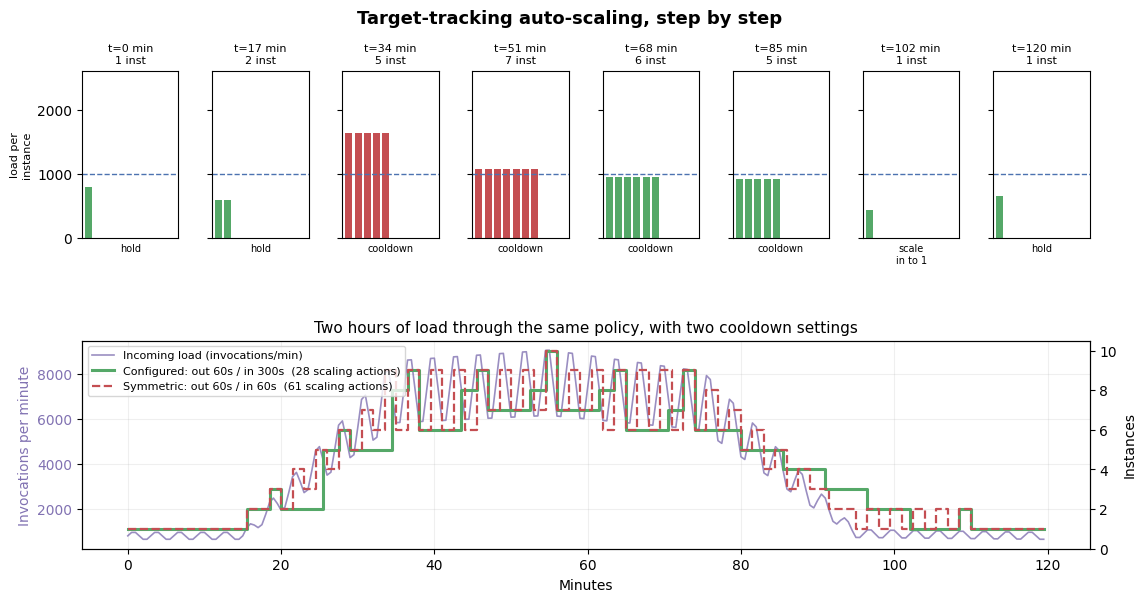


Scaling actions with the configured 60s/300s cooldowns : 28
Scaling actions with symmetric 60s/60s cooldowns     : 61
Extra actions caused by the fast scale-in                 : 33


In [9]:
# WHAT: replay the auto-scaling policy defined above against a two-hour load
# profile, as an 8-frame storyboard plus a full-run comparison.
# WHY: target tracking is a PROCESS — load rises, the policy reacts, a cooldown
# blocks the next reaction. Printed parameters cannot show that; a step sequence can.
import numpy as np
import matplotlib.pyplot as plt

TARGET   = autoscaling_config['policy']['TargetTrackingScalingPolicyConfiguration']['TargetValue']
MIN_I    = autoscaling_config['register']['MinCapacity']
MAX_I    = autoscaling_config['register']['MaxCapacity']
OUT_CD   = autoscaling_config['policy']['TargetTrackingScalingPolicyConfiguration']['ScaleOutCooldown']
IN_CD    = autoscaling_config['policy']['TargetTrackingScalingPolicyConfiguration']['ScaleInCooldown']
DT       = 30  # the policy is evaluated every 30 seconds

# A STATED load profile (invocations/minute), not measured traffic: a morning
# ramp, a plateau, a decline — with a short 3-minute wobble on top, which is
# exactly the kind of variation cooldowns exist to absorb.
mins = np.arange(0, 120, DT / 60)
ramp = np.interp(mins, [0, 15, 35, 55, 75, 95, 119], [800, 800, 7200, 7600, 6800, 900, 800])
load = ramp * (1 + 0.22 * np.sin(2 * np.pi * mins / 3.0))

def replay(scale_out_cooldown, scale_in_cooldown):
    """Target tracking, simplified: desired = ceil(load / target), clamped, gated by a cooldown."""
    n, cooldown, actions, trace = MIN_I, 0, 0, []
    for t, l in zip(mins, load):
        per_instance = l / n
        desired = int(np.clip(np.ceil(l / TARGET), MIN_I, MAX_I))
        if cooldown > 0:
            action, cooldown = 'cooldown', cooldown - DT
        elif desired > n:
            action, n, cooldown, actions = f'scale out to {desired}', desired, scale_out_cooldown, actions + 1
        elif desired < n:
            action, n, cooldown, actions = f'scale in to {desired}', desired, scale_in_cooldown, actions + 1
        else:
            action = 'hold'
        trace.append((t, l, per_instance, n, action))
    return trace, actions

trace_real, actions_real = replay(OUT_CD, IN_CD)          # 60 s out / 300 s in, as configured
trace_sym, actions_sym  = replay(OUT_CD, OUT_CD)          # 60 s both ways, for comparison

inst_real = np.array([r[3] for r in trace_real])
inst_sym  = np.array([r[3] for r in trace_sym])

# --- printed step table: 8 evenly spaced moments of the real policy ---------
frame_idx = np.linspace(0, len(trace_real) - 1, 8).astype(int)
print(f"Target: {TARGET:.0f} invocations/min per instance   Range: {MIN_I}-{MAX_I} instances")
print(f"Cooldowns: scale-out {OUT_CD}s, scale-in {IN_CD}s\n")
print(f"{'min':>6} {'load/min':>9} {'per inst':>9} {'inst':>5}  action")
for i in frame_idx:
    t, l, per, n, act = trace_real[i]
    print(f"{t:6.1f} {l:9.0f} {per:9.0f} {n:5d}  {act}")

# --- the figure: storyboard on top, full run underneath --------------------
fig = plt.figure(figsize=(13, 6.2))
gs = fig.add_gridspec(2, 8, height_ratios=[1.0, 1.25], hspace=0.55, wspace=0.35)

for k, i in enumerate(frame_idx):
    t, l, per, n, act = trace_real[i]
    ax = fig.add_subplot(gs[0, k])
    # one bar per running instance, height = the load that instance is carrying
    colour = '#C44E52' if per > TARGET else '#55A868'
    ax.bar(range(n), [per] * n, color=colour, width=0.75)
    ax.axhline(TARGET, color='#4C72B0', ls='--', lw=1)
    ax.set_xlim(-0.7, MAX_I - 0.3)
    ax.set_ylim(0, 2600)
    ax.set_xticks([])
    ax.set_title(f't={t:.0f} min\n{n} inst', fontsize=8)
    ax.set_xlabel(act.replace('scale ', 'scale\n'), fontsize=7)
    if k == 0:
        ax.set_ylabel('load per\ninstance', fontsize=8)
    else:
        ax.set_yticklabels([])

ax = fig.add_subplot(gs[1, :])
ax.plot(mins, load, color='#8172B2', lw=1.2, alpha=0.8, label='Incoming load (invocations/min)')
ax.set_xlabel('Minutes')
ax.set_ylabel('Invocations per minute', color='#8172B2')
ax.tick_params(axis='y', labelcolor='#8172B2')
ax2 = ax.twinx()
ax2.step(mins, inst_real, where='post', color='#55A868', lw=2.2,
         label=f'Configured: out {OUT_CD}s / in {IN_CD}s  ({actions_real} scaling actions)')
ax2.step(mins, inst_sym, where='post', color='#C44E52', lw=1.6, ls='--',
         label=f'Symmetric: out {OUT_CD}s / in {OUT_CD}s  ({actions_sym} scaling actions)')
ax2.set_ylabel('Instances')
ax2.set_ylim(0, MAX_I + 0.5)
lines = ax.get_lines() + ax2.get_lines()
ax2.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')
ax.set_title('Two hours of load through the same policy, with two cooldown settings', fontsize=11)
ax.grid(alpha=0.2)

fig.suptitle('Target-tracking auto-scaling, step by step', fontsize=13, fontweight='bold')
plt.show()

print()
print(f"Scaling actions with the configured {OUT_CD}s/{IN_CD}s cooldowns : {actions_real}")
print(f"Scaling actions with symmetric {OUT_CD}s/{OUT_CD}s cooldowns     : {actions_sym}")
print(f"Extra actions caused by the fast scale-in                 : {actions_sym - actions_real}")


**🔍 Read the figure.** *Top row:* each frame is the endpoint at one moment — one bar per running instance, the bar height is the load that instance is carrying, and the dashed line is the 1,000 invocations/minute target. Look at frame 3 (`t=34 min`): five instances are each carrying about **1,638 invocations/minute**, well above target and drawn red, while the frame's label reads `cooldown`. The policy has already scaled out once and is not allowed to act again yet. That gap between "over target" and "allowed to react" is what a cooldown *is*, and no printed parameter shows it. By frames 5 and 6 the bars are green again: capacity caught up.

*Bottom panel:* the same two hours end to end. Purple is the incoming load; the solid green step line is the instance count under the configured **60 s out / 300 s in** cooldowns, and the red dashed line is the identical policy with a symmetric **60 s / 60 s** setting. Green climbs with the ramp and comes down in a handful of clean steps — **28 scaling actions** across the run. Red chases every three-minute wobble in the load — **61 actions, more than twice as many** — removing instances it will need again a minute later, each removal paying a fresh instance-startup cost. That is the thrashing the asymmetric cooldown exists to prevent, and it is the answer to Discuss question 3.

## 9. Delete the Endpoint to Avoid Charges

SageMaker endpoints bill by the hour even when idle. Always delete endpoints you are not using.

In [10]:
# WHAT: delete the endpoint (and show the full cleanup checklist).
# WHY: endpoints bill per hour whether or not they serve traffic — forgetting
# this step is the classic cloud-ML budget mistake.
try:
    sm = boto3.client('sagemaker', region_name='us-east-1')
    sm.delete_endpoint(EndpointName=ENDPOINT_NAME)
    print(f"Endpoint '{ENDPOINT_NAME}' deletion initiated.")
    print("Billing stops when the endpoint reaches 'Deleted' status.")

except NoCredentialsError:
    print("[No credentials] Would call: sm.delete_endpoint(EndpointName='iris-classifier-endpoint')")
    print()
    print("Cleanup checklist in production:")
    print("  1. sm.delete_endpoint(EndpointName=...)          # stop billing")
    print("  2. sm.delete_endpoint_config(EndpointConfigName=...) # clean up config")
    print("  3. sm.delete_model(ModelName=...)                # clean up model registry")
    print("  4. s3.delete_object(Bucket=..., Key=...)         # optional: remove artifact")

# 'ValidationException' here just means the endpoint never existed — that is fine.
except ClientError as e:
    if e.response['Error']['Code'] == 'ValidationException':
        print("Endpoint not found (already deleted or never created).")
    else:
        print(f"[AWS error] {e.response['Error']['Code']}: {e.response['Error']['Message']}")

[No credentials] Would call: sm.delete_endpoint(EndpointName='iris-classifier-endpoint')

Cleanup checklist in production:
  1. sm.delete_endpoint(EndpointName=...)          # stop billing
  2. sm.delete_endpoint_config(EndpointConfigName=...) # clean up config
  3. sm.delete_model(ModelName=...)                # clean up model registry
  4. s3.delete_object(Bucket=..., Key=...)         # optional: remove artifact


### What the meter actually charged for

`delete_endpoint` is one line, and the reason it matters is arithmetic the notebook has not yet drawn. The opening box described an endpoint left running for a month that served **eleven requests**. Below, that story is priced at the `ml.m5.large` rate this notebook has been using all along — **$0.115 per instance-hour**, the same number in the `InstanceType` comment in section 5 — against the identical endpoint deleted at the end of a three-hour class.

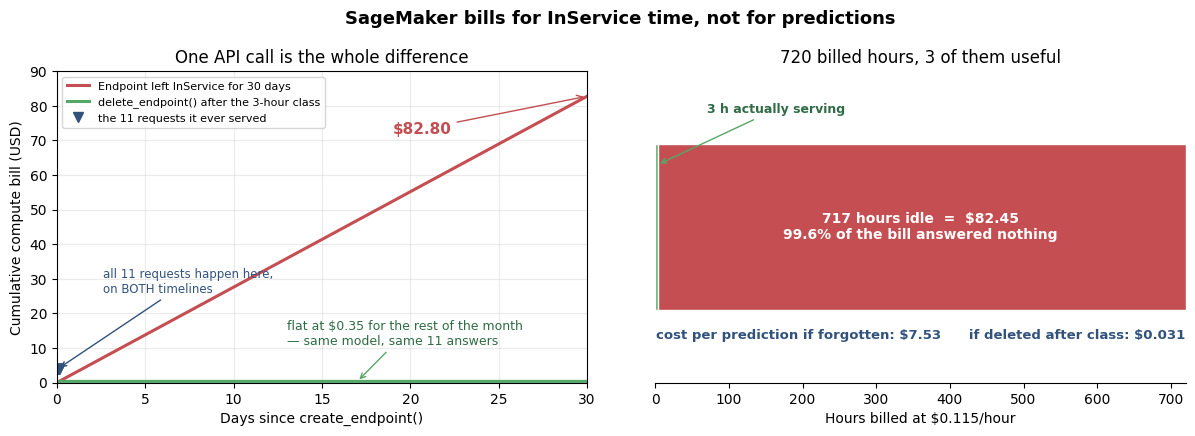

30 days InService, 11 requests served:
  forgotten endpoint : $82.80  ($7.53 per prediction)
  deleted after 3h  : $0.35  ($0.031 per prediction)
  difference         : $82.45 for zero extra predictions


In [11]:
# WHAT: price the forgotten endpoint against the deleted one, using only the
# $0.115/hour rate already stated in the endpoint config above.
# WHY: "endpoints bill by the hour even when idle" is a sentence. The same fact
# as a bill you watch accumulate, and as a strip of hours you paid for but did
# not use, is the thing students actually remember at 2am on a Friday.
import numpy as np
import matplotlib.pyplot as plt

HOURLY       = 0.115      # ml.m5.large, the rate in the endpoint config above
DAYS         = 30
CLASS_HOURS  = 3          # you demo the model, then delete the endpoint
N_REQUESTS   = 11         # the endpoint in the opening box served eleven requests

hours = np.arange(0, DAYS * 24 + 1)
bill_forgotten = hours * HOURLY                              # meter never stops
bill_deleted   = np.minimum(hours, CLASS_HOURS) * HOURLY     # meter stops at deletion
total_forgotten, total_deleted = bill_forgotten[-1], bill_deleted[-1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# --- Left: the same eleven requests, two very different bills ---------------
ax = axes[0]
days_axis = hours / 24
ax.plot(days_axis, bill_forgotten, color='#C44E52', lw=2.2,
        label='Endpoint left InService for 30 days')
ax.plot(days_axis, bill_deleted, color='#55A868', lw=2.2,
        label=f'delete_endpoint() after the {CLASS_HOURS}-hour class')
# The eleven requests all happen during the class, on both timelines.
req_t = np.linspace(0.1, CLASS_HOURS - 0.1, N_REQUESTS) / 24
ax.plot(req_t, np.zeros_like(req_t) + 4.0, marker='v', ls='none', ms=7,
        color='#31527d', label=f'the {N_REQUESTS} requests it ever served')
ax.annotate(f'all {N_REQUESTS} requests happen here,\non BOTH timelines',
            xy=(req_t.mean(), 4.0), xytext=(2.6, 26), fontsize=8.5, color='#31527d',
            arrowprops=dict(arrowstyle='->', color='#31527d'))
ax.annotate(f'\\${total_forgotten:,.2f}', xy=(DAYS, total_forgotten), xytext=(DAYS - 11, 72),
            fontsize=11, fontweight='bold', color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))
ax.annotate(f'flat at \\${total_deleted:,.2f} for the rest of the month\n'
            f'— same model, same {N_REQUESTS} answers',
            xy=(17, total_deleted), xytext=(13, 11), fontsize=9, color='#2f6b45',
            arrowprops=dict(arrowstyle='->', color='#55A868'))
ax.set_xlabel('Days since create_endpoint()')
ax.set_ylabel('Cumulative compute bill (USD)')
ax.set_title('One API call is the whole difference')
ax.set_xlim(0, DAYS); ax.set_ylim(0, 90)
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.25)

# --- Right: what those 720 billed hours were actually doing ------------------
ax = axes[1]
billed_hours = DAYS * 24
idle_hours = billed_hours - CLASS_HOURS
ax.barh([0], [CLASS_HOURS], color='#55A868', edgecolor='white')
ax.barh([0], [idle_hours], left=[CLASS_HOURS], color='#C44E52', edgecolor='white')
ax.set_xlim(0, billed_hours); ax.set_ylim(-0.75, 0.75)
ax.set_yticks([])
ax.set_xlabel('Hours billed at $0.115/hour')
ax.annotate(f'{CLASS_HOURS} h actually serving', xy=(CLASS_HOURS, 0.30), xytext=(70, 0.55),
            fontsize=9, color='#2f6b45', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#55A868'))
ax.text(billed_hours / 2, 0.0, f'{idle_hours} hours idle  =  \\${idle_hours * HOURLY:,.2f}\n'
                               f'{idle_hours / billed_hours:.1%} of the bill answered nothing',
        ha='center', va='center', fontsize=10, color='white', fontweight='bold')
# NOTE: escape the dollar signs or matplotlib parses them as mathtext.
ax.text(billed_hours / 2, -0.52,
        f'cost per prediction if forgotten: \\${total_forgotten / N_REQUESTS:,.2f}'
        f'      if deleted after class: \\${total_deleted / N_REQUESTS:,.3f}',
        ha='center', va='center', fontsize=9.5, color='#31527d', fontweight='bold')
ax.set_title(f'{billed_hours} billed hours, {CLASS_HOURS} of them useful')
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)

fig.suptitle('SageMaker bills for InService time, not for predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"30 days InService, {N_REQUESTS} requests served:")
print(f"  forgotten endpoint : ${total_forgotten:,.2f}  (${total_forgotten / N_REQUESTS:,.2f} per prediction)")
print(f"  deleted after {CLASS_HOURS}h  : ${total_deleted:,.2f}  (${total_deleted / N_REQUESTS:,.3f} per prediction)")
print(f"  difference         : ${total_forgotten - total_deleted:,.2f} for zero extra predictions")


**🔍 Read the figure.** *Left:* two cumulative bills for **the same model answering the same eleven requests** — the blue markers show every request the endpoint ever served, and they all land inside the first three hours on both timelines. The red line keeps climbing anyway, at $0.115 every hour, to **$82.80** after thirty days. The green line stops at **$0.35** because `delete_endpoint()` was called. Nothing about the model, the traffic or the answers differs between the two lines; only one API call does.

*Right:* the same month as the 720 hours you were billed for. Three of them served a request (green); **717 hours — 99.6% of the bill — answered nothing** (red). Divide the bill by the eleven predictions and the forgotten endpoint charged **$7.53 per prediction**, against $0.031 for the deleted one. This is the arithmetic behind the serverless launch quoted at the top of the notebook, and behind Discuss question 2: what you are buying from a real-time endpoint is *readiness*, and readiness is billed whether or not anyone shows up.

## 💬 Discuss

SageMaker deliberately splits one deployment into three objects — **Model** (artifact + container), **EndpointConfig** (instances, counts, traffic weights) and **Endpoint** (the live URL). The notebook's `ProductionVariants` block with `InitialVariantWeight: 1.0` is where an A/B split would live.

1. Why is the traffic weight a property of the *config* rather than of the *endpoint*? Trace what a blue/green update looks like under this design, and what it would look like if the three were one object. Which failure does the split prevent?
2. Serverless inference removes idle cost but adds cold starts — the first request after a quiet period pays for the container to come up. For a fraud-scoring endpoint that sees traffic in bursts, which do you choose? What number would you need to measure to decide rather than guess?
3. Auto-scaling here triggers on `SageMakerVariantInvocationsPerInstance` with a **60 s** scale-out wait and a **300 s** scale-in wait. Why is scale-in deliberately five times slower than scale-out? Describe the failure that symmetric settings would cause.

## Summary

The SageMaker deployment flow has five steps:
1. **Package** — create `model.tar.gz` with your model artifact and inference script
2. **Upload** — push the artifact to an S3 bucket the SageMaker execution role can access
3. **Register** — call `create_model()` pointing to the S3 URI and container image
4. **Configure** — call `create_endpoint_config()` to specify instance type and count
5. **Deploy** — call `create_endpoint()` and wait for `InService` status

Key things to remember:
- The endpoint config is separate from the endpoint, enabling safe blue/green updates
- Auto-scaling uses `SageMakerVariantInvocationsPerInstance` as the default trigger
- Endpoints bill by the hour — delete them when not in use

## Self-Check

1. **What format does SageMaker expect the model artifact in?**
   *(Name the exact file format and what should be inside.)*

2. **What is an endpoint config and why is it separate from the endpoint?**
   *(What does separating them allow you to do when you update a model?)*

3. **How do you avoid being charged for an idle SageMaker endpoint?**
   *(One specific API call. What happens to billing when you make it?)*

## ⚠️ Where this breaks

- **The billing model is the main hazard, and it is silent.** An idle `InService` endpoint costs the same as a busy one. Nothing alerts you. Set a billing alarm on day one, and delete endpoints in the same commit that created them for anything experimental — `delete_endpoint` is the call that stops the meter, not `delete_model`.
- **Managed does not mean isolated from the region.** Your endpoint lives in one AWS region and inherits its failures. The `us-east-1` event of 19–20 October 2025 took about 14 and a half hours to fully resolve, by AWS's own timeline and, while it lasted, prevented new EC2 instances from launching — so neither auto-scaling nor a redeploy would have helped. A single-region managed endpoint has single-region availability, whatever the SLA says.
- **You inherit the provider's container, including its versions.** `sagemaker-scikit-learn:1.2-1-cpu-py3` pins a scikit-learn version that is not yours. An artifact saved under a newer sklearn may load with warnings, load wrongly, or not load at all. Match the training environment to the serving container explicitly, or bring your own image.
- **The assumption that must hold:** the execution role can read the S3 path, and the S3 path still contains what you think. IAM is where most first SageMaker deployments actually fail, and the error surfaces minutes later as an endpoint stuck in `Creating` — a slow, expensive way to learn about a permission.
- **Everything above ran without credentials.** Every call in this notebook printed what it *would* send. That is honest teaching, but it means you have not seen a real `InService` transition, a real cold start, or a real bill. Treat this as the API map, and budget a real account for the territory.
- **The cheaper alternative.** For a low-traffic internal model, a single container on a small VM — or a serverless container platform that scales to zero — costs a fraction of a dedicated endpoint and needs no platform-specific SDK in your inference code. Reach for SageMaker when you want its A/B, monitoring and registry features, not merely because you want an HTTPS URL.

## 🔭 State of the field (2026)

`SageMakerVariantInvocationsPerInstance` with a 60 s / 300 s cooldown pair is still how you autoscale the endpoint you just built, and idle instance-hours are still billed exactly as section 9 prices them. What changed is what sits behind the endpoint. When the deployed model is a language model, requests-per-instance stops being a good load signal: throughput is governed by continuous batching and by how much KV cache fits in GPU memory, so 2026 serving systems scale on queue depth, time-to-first-token and cache occupancy, and they treat the prefill and decode stages as separately scaled pools rather than as one replica count (Li et al., 2025). The idle-cost problem this notebook prices at **$7.53 per prediction** also acquired a second answer: serverless inference for models has moved past "cold starts make it unusable" towards on-demand sharing of heterogeneous hardware, including otherwise idle CPU capacity (Xu et al., 2025).

None of that changes why you learn this here. Model / EndpointConfig / Endpoint as three separate objects, a scale-in cooldown five times slower than scale-out, and one delete call that stops the meter are the same three ideas whatever unit the trigger metric is counted in — and they are what the official plan examines.

- Li, R., et al. (2025). *Taming the Chaos: Coordinated Autoscaling for Heterogeneous and Disaggregated LLM Inference*. <https://arxiv.org/abs/2508.19559>
- Xu, C., et al. (2025). *Towards Resource-Efficient Serverless LLM Inference with SLINFER*. <https://arxiv.org/abs/2507.00507>

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
3. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2022). *Operationalizing Machine Learning: An Interview Study*. arXiv. <https://arxiv.org/abs/2209.09125>
4. Li, R., Du, R., Chu, Z., et al. (2025). *Taming the Chaos: Coordinated Autoscaling for Heterogeneous and Disaggregated LLM Inference*. arXiv. <https://arxiv.org/abs/2508.19559>
5. Xu, C., Li, Z., Chen, Q., Zhao, H., Tang, X., & Guo, M. (2025). *Towards Resource-Efficient Serverless LLM Inference with SLINFER*. arXiv. <https://arxiv.org/abs/2507.00507>
